# Bankruptcy Risk Prediction Using Financial Ratios

## Project Goal

This project aims to predict whether a company is likely to go bankrupt using financial indicators from Polish companies.

### Objectives

- Analyze financial health indicators
- Identify variables associated with bankruptcy
- Understand class imbalance
- Detect outliers and anomalies
- Explore feature relationships
- Prepare data for predictive modeling

### Dataset

Polish Companies Bankruptcy Dataset

Source: UCI Machine Learning Repository

In [64]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

%matplotlib inline

In [65]:
DATA_PATH = "../data/bankruptcy.csv"

df = pd.read_csv(DATA_PATH)

# Standardize target name
df = df.rename(columns={"class": "Bankrupt"})

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (43405, 66)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16,A17,A18,A19,A20,A21,A22,A23,A24,A25,A26,A27,A28,A29,A30,A31,A32,A33,A34,A35,A36,A37,A38,A39,A40,A41,A42,A43,A44,A45,A46,A47,A48,A49,A50,A51,A52,A53,A54,A55,A56,A57,A58,A59,A60,A61,A62,A63,A64,Bankrupt,year
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,0.249760,0.65980,0.166600,0.249760,497.42,0.73378,2.6349,0.249760,0.149420,43.370,1.2479,0.21402,0.119980,0.47706,0.50494,0.60411,1.45820,1.7615,5.9443,0.11788,0.149420,94.14,3.8772,0.56393,0.21402,1.7410,593.2700,0.50591,0.128040,0.662950,0.051402,0.128040,114.42,71.050,1.00970,1.52250,49.394,0.185300,0.110850,2.0420,0.37854,0.25792,2.2437,2.2480,348690.0,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0,1
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,0.261140,0.51680,0.158350,0.258340,677.96,0.53838,2.0005,0.258340,0.152000,87.981,1.4293,0.24806,0.123040,NaN,0.39542,0.43992,88.44400,16.9460,3.6884,0.26969,0.152000,122.17,2.9876,2.98760,0.20616,1.6996,NaN,0.49788,0.121300,0.086422,0.064371,0.145950,199.49,111.510,0.51045,1.12520,100.130,0.237270,0.139610,1.9447,0.49988,0.33472,17.8660,17.8660,2304.6,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0,1
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,0.312580,0.64184,0.244350,0.309060,794.16,0.45961,1.4369,0.309060,0.236100,73.133,1.4283,0.30260,0.189960,NaN,0.28932,0.37282,86.01100,1.0627,4.3749,0.41929,0.238150,176.93,2.0630,1.42740,0.31565,1.3090,2.3019,0.51537,0.241140,0.322020,0.074020,0.231170,165.51,92.381,0.94807,1.01010,96.372,0.291810,0.222930,1.0758,0.48152,0.48474,1.2098,2.0504,6332.7,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0,1
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,0.092704,0.30163,0.094257,0.092704,917.01,0.39803,3.2537,0.092704,0.071428,79.788,1.5069,0.11550,0.062782,0.17193,0.57353,0.36152,0.94076,1.9618,4.6511,0.14343,0.071428,91.37,3.9948,0.37581,0.11550,1.3562,NaN,0.57353,0.088995,0.401390,0.069622,0.088995,180.77,100.980,0.28720,1.56960,84.344,0.085874,0.066165,2.4928,0.30734,0.25033,2.4524,2.4524,20545.0,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0,1
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,0.187320,0.33147,0.121820,0.187320,1133.20,0.32211,1.6307,0.187320,0.115530,57.045,NaN,0.19832,0.115530,0.18732,0.38677,0.32211,1.41380,1.1184,4.1424,0.27884,0.115530,147.04,2.4823,0.32340,0.19832,1.6278,11.2470,0.43489,0.122310,0.293040,0.096680,0.122310,141.62,84.574,0.73919,0.95787,65.936,0.188110,0.116010,1.2959,0.56511,0.40285,1.8839,2.1184,3186.6,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0,1


# Dataset Overview

In [66]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData Types\n")
print(df.dtypes.value_counts())

Rows: 43405
Columns: 66

Data Types

float64    64
int64       2
Name: count, dtype: int64


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43405 entries, 0 to 43404
Data columns (total 66 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   A1        43397 non-null  float64
 1   A2        43397 non-null  float64
 2   A3        43397 non-null  float64
 3   A4        43271 non-null  float64
 4   A5        43316 non-null  float64
 5   A6        43397 non-null  float64
 6   A7        43397 non-null  float64
 7   A8        43311 non-null  float64
 8   A9        43396 non-null  float64
 9   A10       43397 non-null  float64
 10  A11       43361 non-null  float64
 11  A12       43271 non-null  float64
 12  A13       43278 non-null  float64
 13  A14       43397 non-null  float64
 14  A15       43369 non-null  float64
 15  A16       43310 non-null  float64
 16  A17       43311 non-null  float64
 17  A18       43397 non-null  float64
 18  A19       43277 non-null  float64
 19  A20       43278 non-null  float64
 20  A21       37551 non-null  float64
 21  

In [68]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
A1,43397.0,0.035160,2.994109,-4.638900e+02,0.003429,0.04966,0.12958,9.428000e+01
A2,43397.0,0.590212,5.842748,-4.308700e+02,0.268980,0.47190,0.68832,4.809600e+02
A3,43397.0,0.114431,5.439429,-4.799600e+02,0.021521,0.19661,0.40339,2.833600e+01
A4,43271.0,6.314702,295.434425,-4.031100e-01,1.049500,1.56980,2.78745,5.343300e+04
A5,43316.0,-385.346602,61243.025874,-1.190300e+07,-49.080000,-1.03450,50.63425,1.250100e+06
...,...,...,...,...,...,...,...,...
A62,43278.0,1502.327833,139266.699576,-2.336500e+06,42.144000,71.32600,117.22000,2.501600e+07
A63,43271.0,9.343074,124.177354,-1.543200e+00,3.097650,5.08760,8.59885,2.345400e+04
A64,42593.0,72.788592,2369.339482,-1.067700e+04,2.176800,4.28250,9.77620,2.947700e+05
Bankrupt,43405.0,0.048174,0.214137,0.000000e+00,0.000000,0.00000,0.00000,1.000000e+00


# Data Quality Assessment

In [69]:
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (
        missing_values / len(df) * 100
    ).round(2)
})

missing_df = missing_df[
    missing_df["Missing Values"] > 0
].sort_values(
    by="Missing Values",
    ascending=False
)

if len(missing_df) > 0:
    display(missing_df.head(20))
else:
    print("No missing values found.")

,Missing Values,Percentage
A37,18984,43.74
A21,5854,13.49
A27,2764,6.37
A60,2152,4.96
A45,2147,4.95
A24,922,2.12
A28,812,1.87
A64,812,1.87
A53,812,1.87
A54,812,1.87


In [70]:
print(
    f"Duplicate Rows: {df.duplicated().sum()}"
)

print(
    f"Memory Usage: {round(df.memory_usage(deep=True).sum() / 1024**2, 2)} MB"
)

Duplicate Rows: 401
Memory Usage: 21.86 MB


#Forecast Horizon Analysis

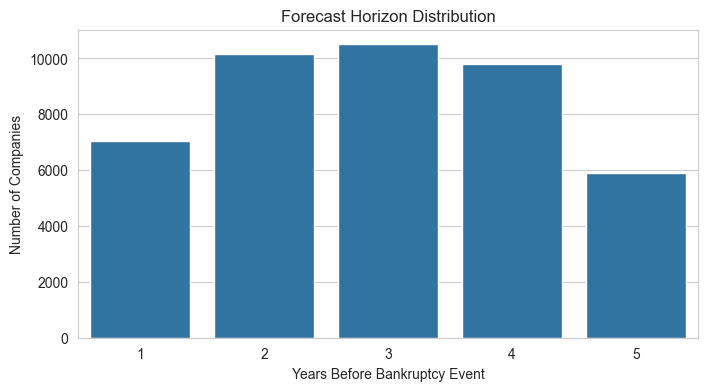

year
1     7027
2    10173
3    10503
4     9792
5     5910
Name: count, dtype: int64

In [71]:
year_counts = (
    df["year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 4))

sns.barplot(
    x=year_counts.index,
    y=year_counts.values
)

plt.title(
    "Forecast Horizon Distribution"
)

plt.xlabel(
    "Years Before Bankruptcy Event"
)

plt.ylabel(
    "Number of Companies"
)

plt.show()

year_counts

# Bankruptcy Class Analysis

In [72]:
df.columns

Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11',
       'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21',
       'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31',
       'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41',
       'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51',
       'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61',
       'A62', 'A63', 'A64', 'Bankrupt', 'year'],
      dtype='str')

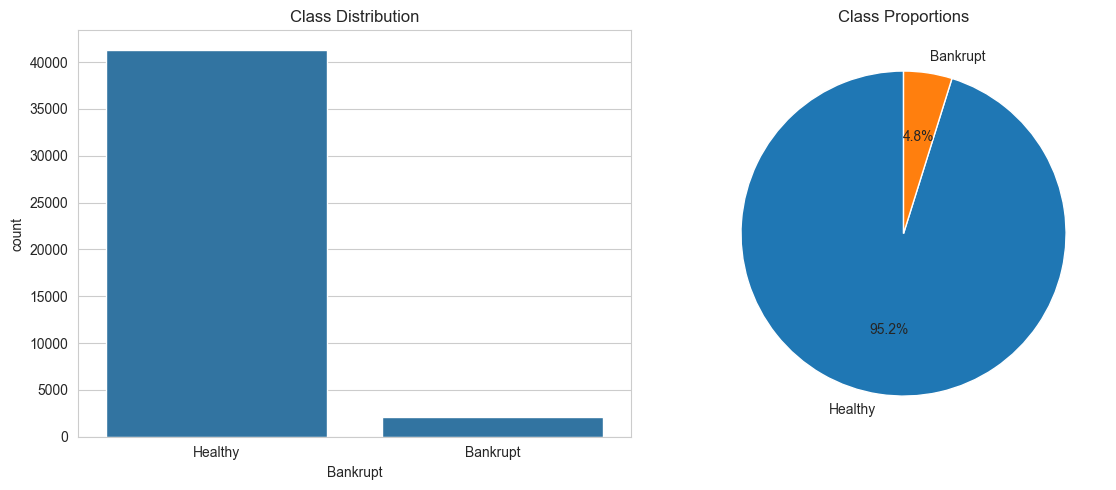

In [73]:
target_counts = (
    df["Bankrupt"]
    .value_counts()
    .sort_index()
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

sns.countplot(
    x="Bankrupt",
    data=df,
    ax=axes[0]
)

axes[0].set_title(
    "Class Distribution"
)

axes[0].set_xticklabels(
    ["Healthy", "Bankrupt"]
)

axes[1].pie(
    target_counts,
    labels=["Healthy", "Bankrupt"],
    autopct="%1.1f%%",
    startangle=90
)

axes[1].set_title(
    "Class Proportions"
)

plt.tight_layout()

plt.show()

In [74]:
healthy = (
    df["Bankrupt"] == 0
).sum()

bankrupt = (
    df["Bankrupt"] == 1
).sum()

print(
    f"Healthy Companies : {healthy}"
)

print(
    f"Bankrupt Companies : {bankrupt}"
)

print(
    f"Imbalance Ratio : {healthy / bankrupt:.2f}:1"
)

Healthy Companies : 41314
Bankrupt Companies : 2091
Imbalance Ratio : 19.76:1


# Bankruptcy by Forecast Horizon 

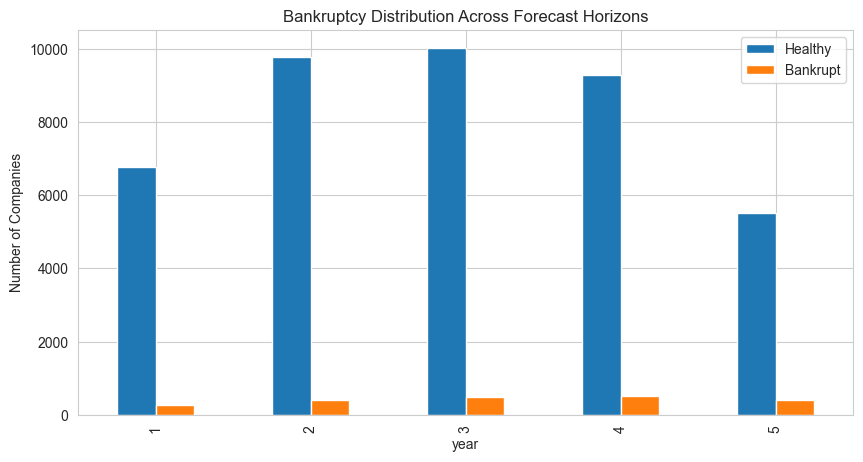

,Healthy,Bankrupt
year,,
1,6756,271
2,9773,400
3,10008,495
4,9277,515
5,5500,410


In [75]:
year_bankruptcy = pd.crosstab(
    df["year"],
    df["Bankrupt"]
)

year_bankruptcy.columns = [
    "Healthy",
    "Bankrupt"
]

year_bankruptcy.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Bankruptcy Distribution Across Forecast Horizons"
)

plt.ylabel(
    "Number of Companies"
)

plt.show()

year_bankruptcy

# Numeric Feature Selection

In [76]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_cols = [
    col
    for col in numeric_cols
    if col not in ["Bankrupt"]
]

# Top Features by Correlation

In [77]:
top_features = (
    df.corr(numeric_only=True)["Bankrupt"]
    .drop("Bankrupt")
    .abs()
    .sort_values(ascending=False)
    .head(12)
    .index
    .tolist()
)

print("Top Features:")

top_features

Top Features:


['A29',
 'year',
 'A2',
 'A3',
 'A51',
 'A6',
 'A1',
 'A55',
 'A39',
 'A57',
 'A25',
 'A35']

# Feature Distribution Analysis

In [78]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_cols.remove("Bankrupt")

len(numeric_cols)

65

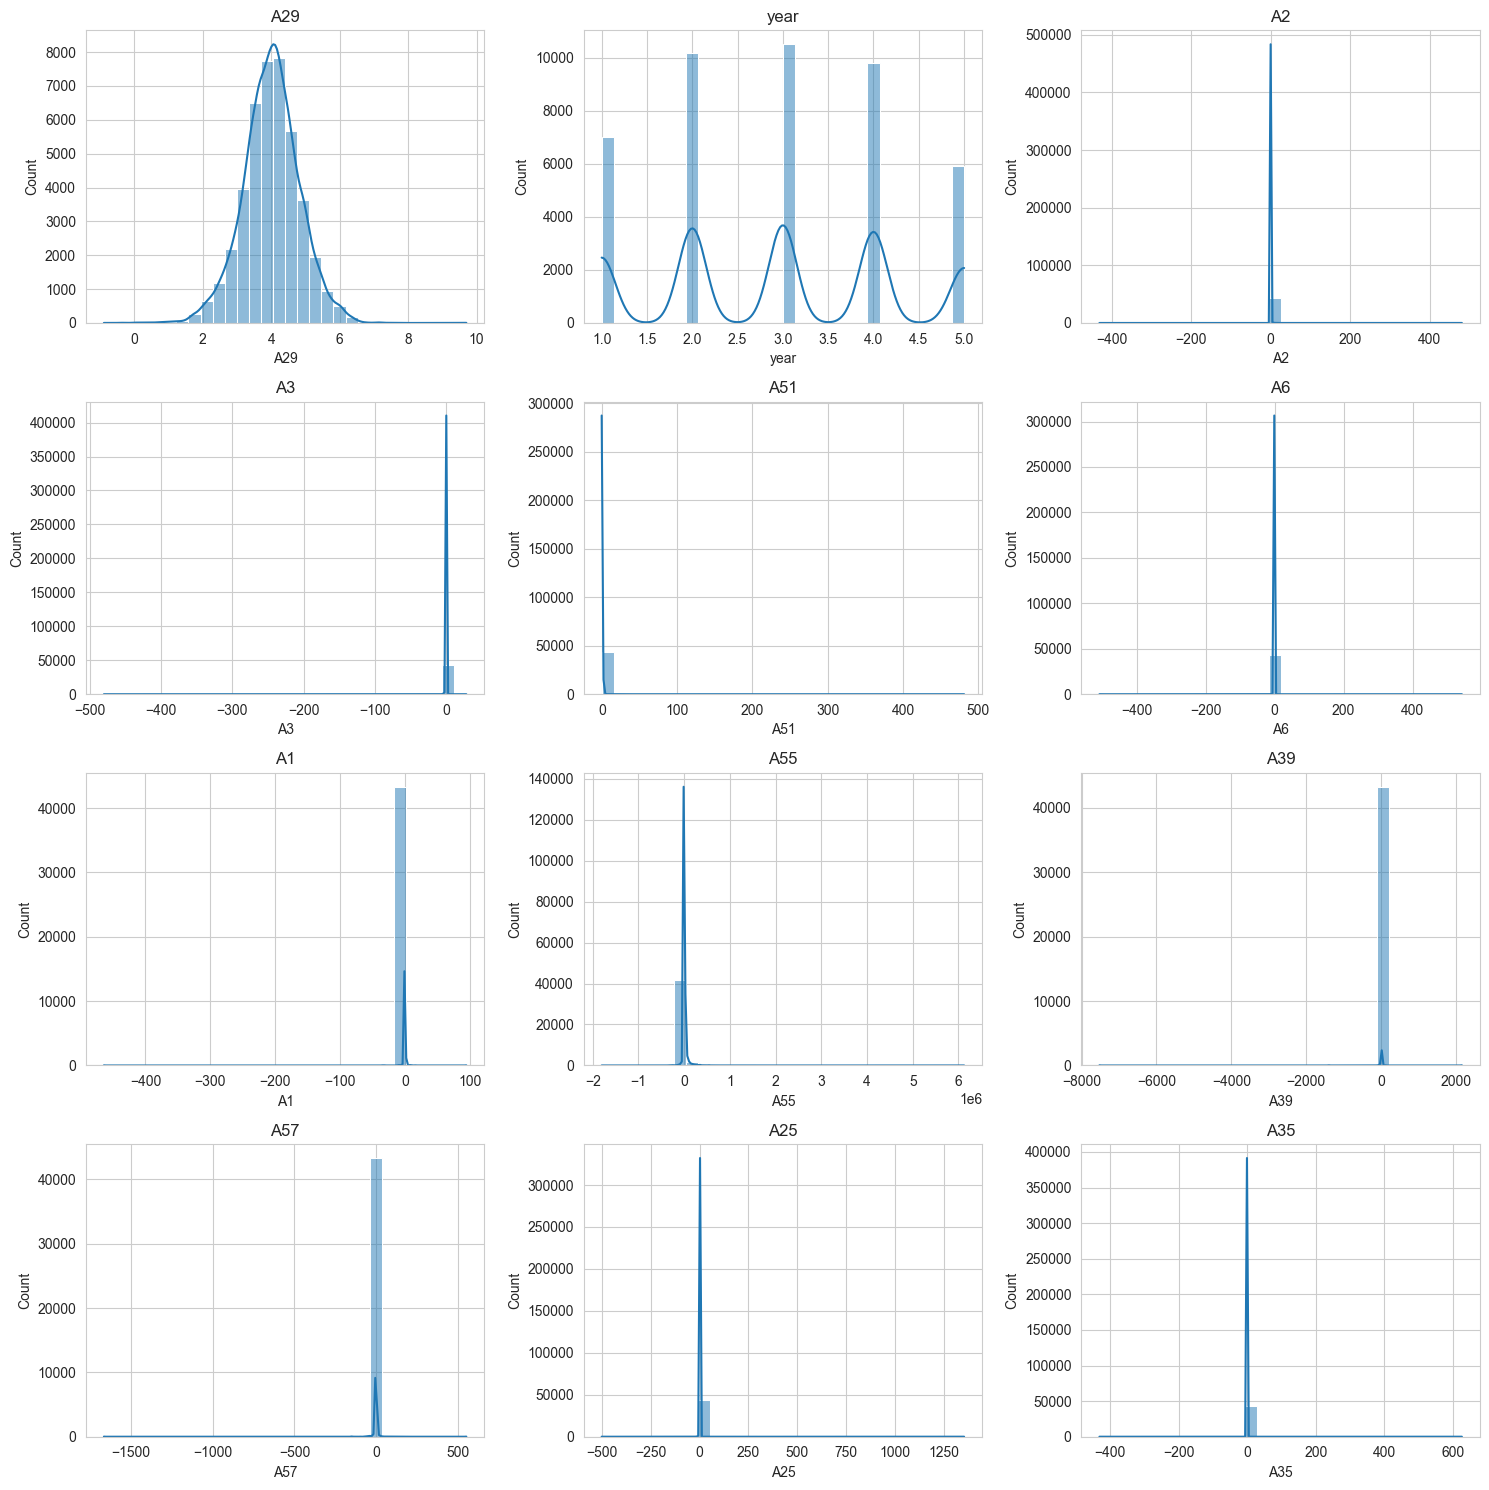

In [79]:
fig, axes = plt.subplots(
    4,
    3,
    figsize=(15, 15)
)

axes = axes.flatten()

for i, col in enumerate(top_features):

    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

# Outlier Analysis

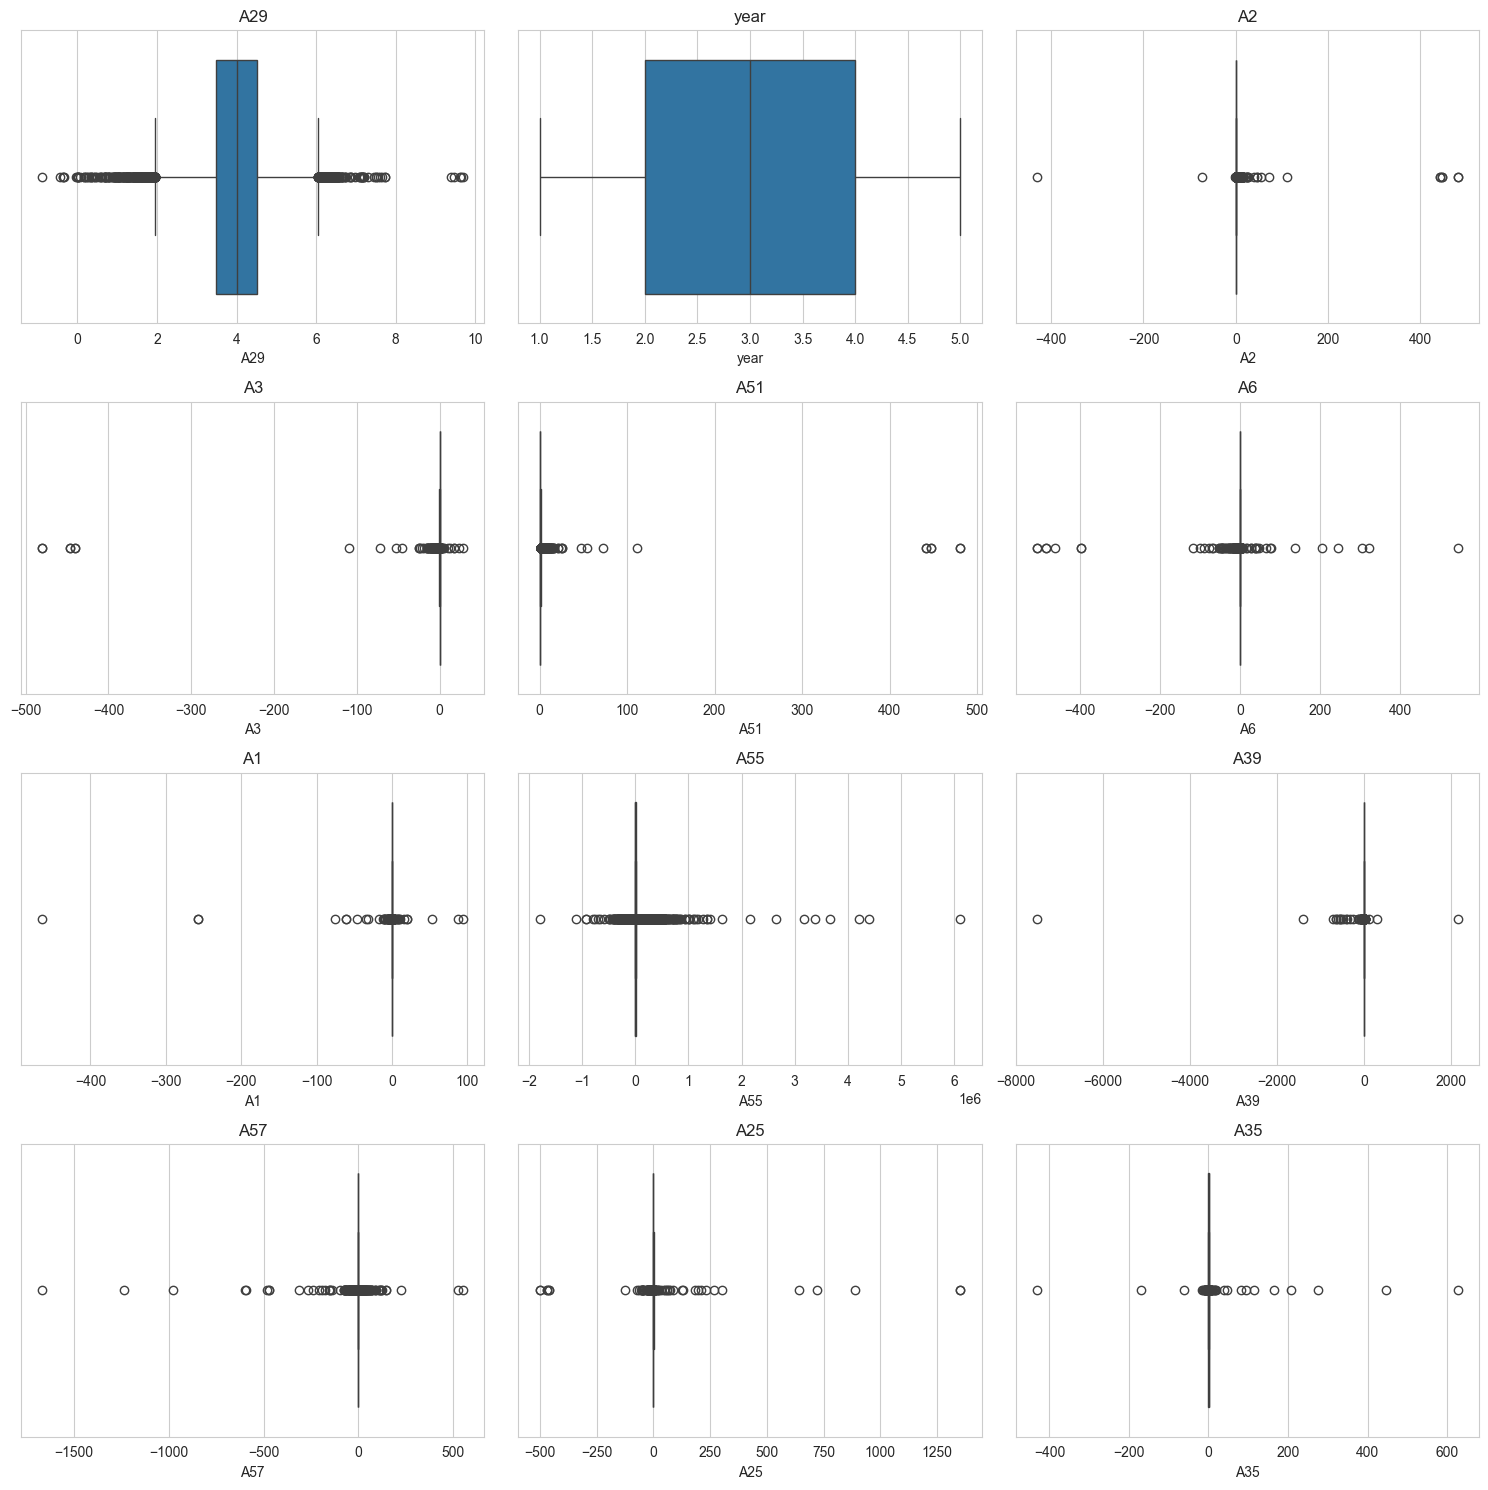

In [80]:
fig, axes = plt.subplots(
    4,
    3,
    figsize=(15, 15)
)

axes = axes.flatten()

for i, col in enumerate(top_features):

    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()

plt.show()

In [81]:
outlier_summary = []

for col in numeric_cols:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = (
        (df[col] < lower)
        |
        (df[col] > upper)
    ).sum()

    outlier_summary.append(
        [
            col,
            outliers,
            round(
                outliers /
                len(df) *
                100,
                2
            )
        ]
    )

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Feature",
        "Outlier Count",
        "Outlier %"
    ]
)

outlier_df.sort_values(
    "Outlier %",
    ascending=False
).head(15)

,Feature,Outlier Count,Outlier %
5,A6,11197,25.80
26,A27,8306,19.14
54,A55,7354,16.94
14,A15,7286,16.79
44,A45,6953,16.02
40,A41,6928,15.96
58,A59,6794,15.65
4,A5,6198,14.28
53,A54,6017,13.86
27,A28,5964,13.74


# Correlation Analysis

In [82]:
target_corr = (
    df.corr(numeric_only=True)
    ["Bankrupt"]
    .drop("Bankrupt")
    .sort_values(
        key=abs,
        ascending=False
    )
)

target_corr.head(15)

A29    -0.055717
year    0.043488
A2      0.035236
A3     -0.035128
A51     0.034753
A6     -0.034662
A1     -0.026649
A55    -0.022101
A39    -0.019850
A57    -0.019204
A25    -0.018415
A35    -0.018003
A11    -0.016147
A12    -0.016108
A18    -0.016053
Name: Bankrupt, dtype: float64

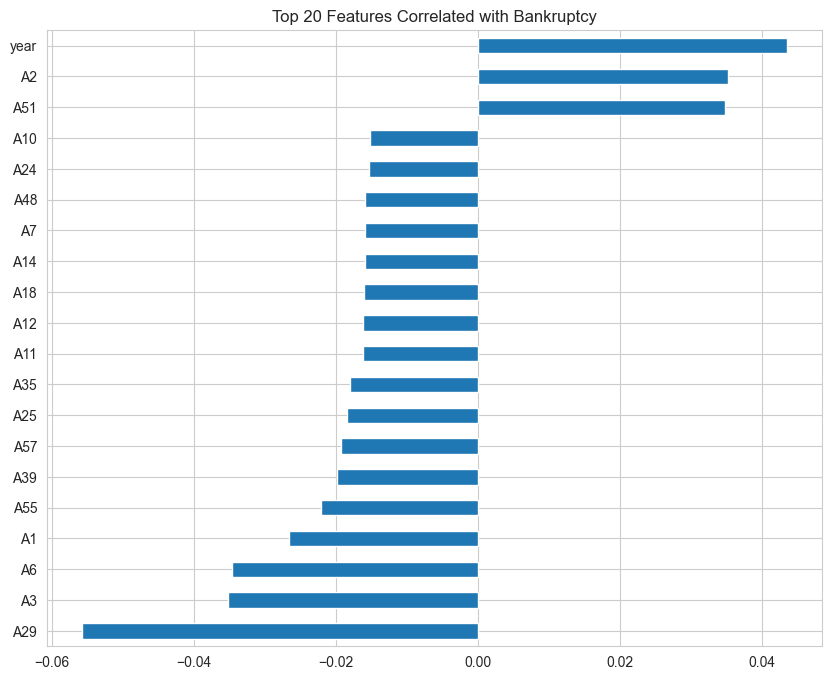

In [83]:
plt.figure(
    figsize=(10, 8)
)

target_corr.head(20).sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 20 Features Correlated with Bankruptcy"
)

plt.show()

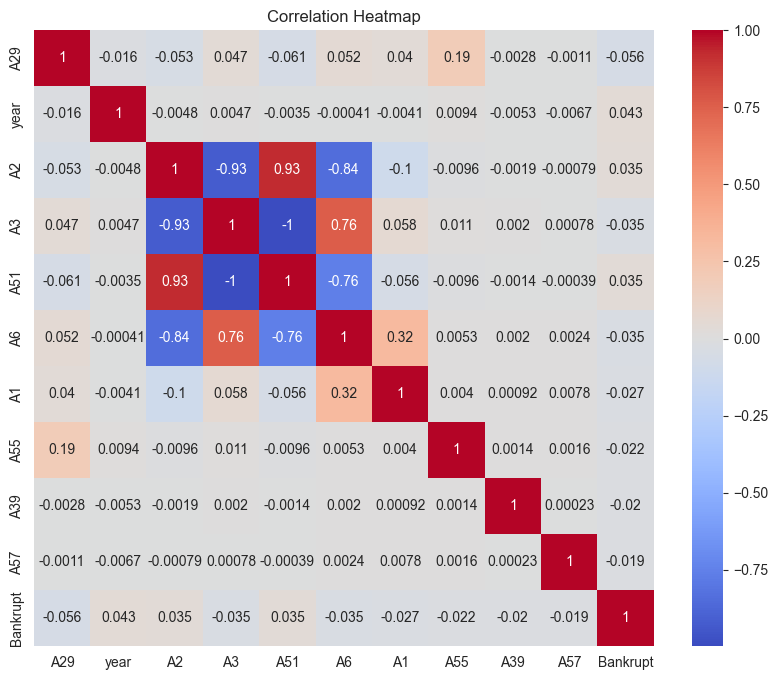

In [84]:
top_corr_features = (
    target_corr.head(10)
    .index
    .tolist()
)

corr_matrix = df[
    top_corr_features +
    ["Bankrupt"]
].corr()

plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

# PCA Visualization

In [85]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X = df.drop(
    columns=[
        "Bankrupt",
        "year"
    ]
)

y = df["Bankrupt"]

imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

In [86]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Bankrupt"] = y.values

In [87]:
print(
    f"Explained Variance Ratio: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

Explained Variance Ratio: 29.07%


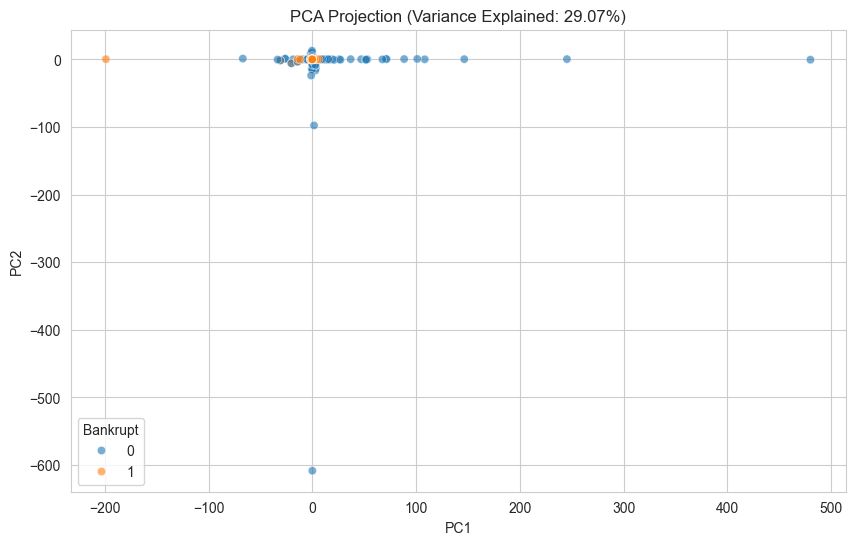

In [88]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Bankrupt",
    alpha=0.6
)

plt.title(
    f"PCA Projection "
    f"(Variance Explained: {pca.explained_variance_ratio_.sum():.2%})"
)

plt.show()

# Bankruptcy Rate by Forecast Horizon

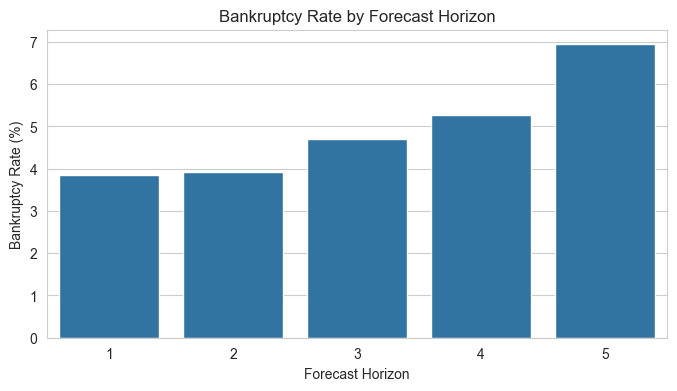

year
1    3.86
2    3.93
3    4.71
4    5.26
5    6.94
Name: Bankrupt, dtype: float64

In [89]:
bankruptcy_rate = (
    df.groupby("year")["Bankrupt"]
    .mean()
    .mul(100)
    .round(2)
)

plt.figure(figsize=(8, 4))

sns.barplot(
    x=bankruptcy_rate.index,
    y=bankruptcy_rate.values
)

plt.ylabel("Bankruptcy Rate (%)")
plt.xlabel("Forecast Horizon")
plt.title("Bankruptcy Rate by Forecast Horizon")

plt.show()

bankruptcy_rate

# Key Findings

### Dataset Characteristics

- Severe class imbalance exists.
- Financial ratios contain significant outliers.
- Several features show strong correlation with bankruptcy.
- PCA indicates partial separation between healthy and bankrupt firms.

### Implications

- Class imbalance techniques will be required.
- Outlier treatment is necessary.
- Feature selection may improve model performance.
- Bankruptcy prediction appears feasible using financial indicators.